In [ ]:
pip install matplotlib networkx mlxtend

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


Association Rules:
        antecedents      consequents  support  confidence      lift
0          (Butter)          (Bread)      0.6    0.750000  0.937500
1           (Bread)         (Butter)      0.6    0.750000  0.937500
2            (Milk)          (Bread)      0.6    0.750000  0.937500
3           (Bread)           (Milk)      0.6    0.750000  0.937500
4            (Milk)         (Butter)      0.6    0.750000  0.937500
5          (Butter)           (Milk)      0.6    0.750000  0.937500
6    (Milk, Butter)          (Bread)      0.4    0.666667  0.833333
7     (Milk, Bread)         (Butter)      0.4    0.666667  0.833333
8   (Bread, Butter)           (Milk)      0.4    0.666667  0.833333
9            (Milk)  (Bread, Butter)      0.4    0.500000  0.833333
10         (Butter)    (Milk, Bread)      0.4    0.500000  0.833333
11          (Bread)   (Milk, Butter)      0.4    0.500000  0.833333


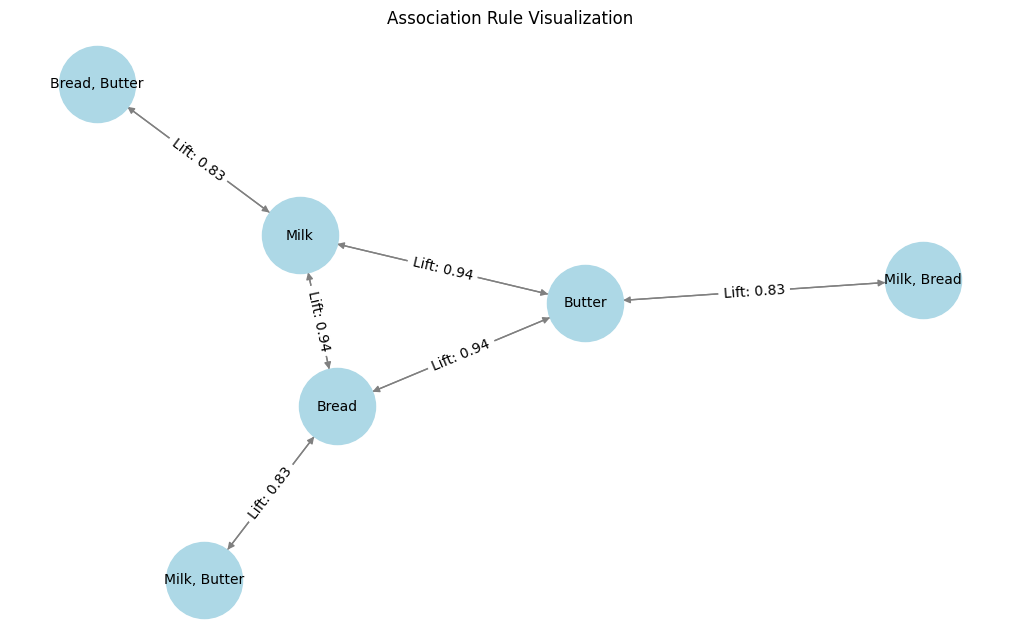

In [4]:
dataset = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Butter']
]

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

min_support = 0.3
min_confidence = 0.3
min_lift = 0.5

frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift)
filtered_rules = rules[(rules['confidence'] >= min_confidence)]

print("\nAssociation Rules:")
print(filtered_rules[['antecedents','consequents','support','confidence','lift']])

def visualize_rules(rules_df):
    if rules_df.empty:
        print("No strong association rules found to visualize.")
        return
    G=nx.DiGraph()
    for _,rule in rules_df.iterrows():
        antecedent=', '.join(rule['antecedents'])
        consequent=', '.join(rule['consequents'])
        G.add_edge(antecedent,consequent,weight=round(rule['lift'],2))
    plt.figure(figsize=(10,6))
    pos=nx.spring_layout(G,seed=42)
    labels={edge:f"Lift: {G[edge[0]][edge[1]]['weight']}"for edge in G.edges}
    nx.draw(G,pos,with_labels=True,node_color="lightblue",edge_color="gray",node_size=3000,font_size=10)
    nx.draw_networkx_edge_labels(G,pos,edge_labels=labels,font_size=10)
    plt.title("Association Rule Visualization")
    plt.show()

visualize_rules(filtered_rules)

🔴 Linear Regression Performance:
MSE: 34362558.7940754
R² Score: 0.9871722458272979


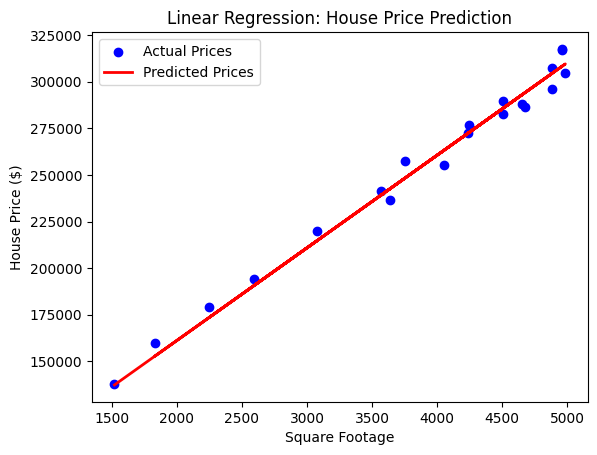

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
size = 100
X = 1000 + np.random.randint(500, 4000, size).reshape(-1, 1)
y = 50000 + (X * 50) + np.random.randint(2000, 20000, size).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("🔴 Linear Regression Performance:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

plt.scatter(X_test, y_test, color="blue", label="Actual Prices")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted Prices")
plt.xlabel("Square Footage")
plt.ylabel("House Price ($)")
plt.title("Linear Regression: House Price Prediction")
plt.legend()
plt.show()

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - loss: 0.4993 - mae: 0.6907 - val_loss: 0.5404 - val_mae: 0.7205
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.4001 - mae: 0.6185 - val_loss: 0.4466 - val_mae: 0.6546
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.3329 - mae: 0.5627 - val_loss: 0.3620 - val_mae: 0.5891
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2676 - mae: 0.5043 - val_loss: 0.2898 - val_mae: 0.5268
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.2160 - mae: 0.4527 - val_loss: 0.2273 - val_mae: 0.4663
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1663 - mae: 0.3967 - val_loss: 0.1750 - val_mae: 0.4088
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1280 - mae: 0.3477 - val_loss: 0.1303 - val_mae: 0.3521
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0911 - mae: 0.2925 - val_loss: 0.0924 - val_mae: 0.2957
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0656 - mae: 0.2462 - va

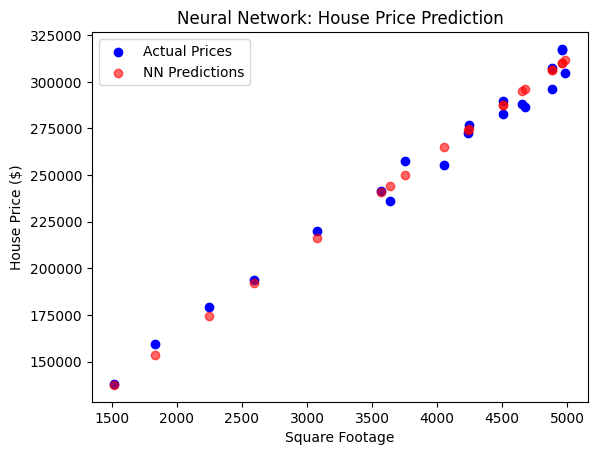

In [7]:
#Neural network
import tensorflow as tf
from tensorflow import keras

X_train_nn = X_train / X_train.max()
X_test_nn = X_test / X_test.max()
y_train_nn = y_train / y_train.max()
y_test_nn = y_test / y_test.max()

model_nn = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(1,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model_nn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_nn.fit(X_train_nn, y_train_nn, epochs=100, verbose=1, validation_data=(X_test_nn, y_test_nn))
y_pred_nn = model_nn.predict(X_test_nn) * y_test.max()

# print("🔴 Neural Network Performance:")
# print("MSE:", mean_squared_error(y_test, y_pred_nn))
# print("R² Score:", r2_score(y_test, y_pred_nn))

plt.scatter(X_test, y_test, color="blue", label="Actual Prices")
plt.scatter(X_test, y_pred_nn, color="red", label="NN Predictions", alpha=0.6)
plt.xlabel("Square Footage")
plt.ylabel("House Price ($)")
plt.title("Neural Network: House Price Prediction")
plt.legend()
plt.show()